In [1]:
import sys
import types
m = types.ModuleType('pyjks')
sys.modules['pyjks'] = m

import os
from dotenv import load_dotenv
import hopsworks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()
API_KEY_HS = os.getenv('API_KEY_HS')

project = hopsworks.login(
    api_key_value=API_KEY_HS,
    project="Pearls_AQI_Predictor12",
    host="eu-west.cloud.hopsworks.ai"
)
fs = project.get_feature_store()
fg = fs.get_feature_group("karachi_aqi_openmeteo", version=1)

df = fg.read(online=True)
print(f"Loaded {len(df)} rows")
df.head()

2026-06-07 22:21:08,808 WARNING: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'

2026-06-07 22:21:08,817 WARNING: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'

2026-06-07 22:21:08,821 WARNING: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'

2026-06-07 22:21:09,496 WARNING: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'

2026-06-07 22:21:09,791 WARNING: In C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: 'parseString' deprecated - use 'parse_string'
2026-06-07 22:21:09,806 WARNING: In C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: 'resetCache' deprecated - use 'reset_cache'
2026-06-07 22:21:12,407 INFO: Initiali

,event_timestamp,pm2_5,pm10,co,no2,so2,o3,european_aqi,wind_speed,wind_direction,temperature,humidity,precipitation,pressure,location,aqi_is_poor,pm25_exceeds_who
0,2026-05-22 14:00:00,45.6,143.9,230.0,3.8,6.2,103.0,82.0,14.1,227.0,32.9,60.0,0.0,1006.1,Karachi_Lyari,1,1
1,2013-01-01 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,265.0,17.9,57.0,0.0,1012.7,Karachi_Lyari,0,0
2,2013-01-06 11:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.1,99.0,20.5,40.0,0.0,1017.1,Karachi_Lyari,0,0
3,2013-01-06 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.2,231.0,19.7,62.0,0.0,1015.1,Karachi_Lyari,0,0
4,2013-01-17 06:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.6,30.0,16.2,68.0,0.0,1013.3,Karachi_Lyari,0,0


Rows with all pollution = 0: 84053/117506 (71.5%)

Data quality by year:
      total_rows  zero_pm25   avg_pm25  zero_pct
year                                            
2013        8760       8760   0.000000     100.0
2014        8760       8760   0.000000     100.0
2015        8760       8760   0.000000     100.0
2016        8784       8784   0.000000     100.0
2017        8760       8760   0.000000     100.0
2018        8760       8760   0.000000     100.0
2019        8760       8760   0.000000     100.0
2020        8784       8784   0.000000     100.0
2021        8760       8760   0.000000     100.0
2022        8760       5165  16.923756      59.0
2023        8760          0  32.670537       0.0
2024        8784          0  26.770128       0.0
2025        8760          0  29.183756       0.0
2026        3554          0  28.792797       0.0


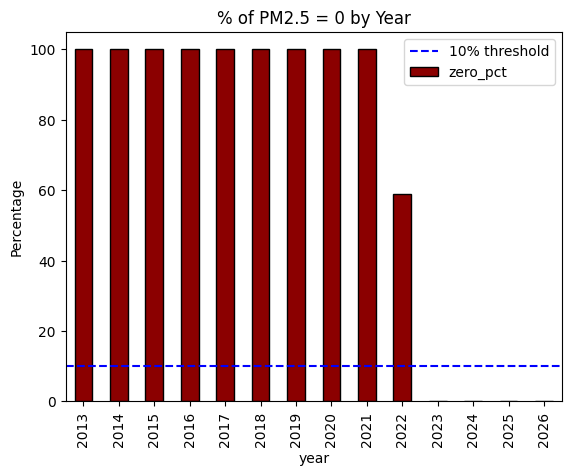

In [2]:
zero_pollution = (df['pm2_5'] == 0) & (df['pm10'] == 0) & (df['co'] == 0)
print(f"Rows with all pollution = 0: {zero_pollution.sum()}/{len(df)} ({zero_pollution.mean()*100:.1f}%)")

df['year'] = df['event_timestamp'].dt.year
yearly_quality = df.groupby('year').agg(
    total_rows=('pm2_5', 'count'),
    zero_pm25=('pm2_5', lambda x: (x == 0).sum()),
    avg_pm25=('pm2_5', 'mean')
)
yearly_quality['zero_pct'] = (yearly_quality['zero_pm25'] / yearly_quality['total_rows'] * 100).round(1)
print("\nData quality by year:")
print(yearly_quality)

import matplotlib.pyplot as plt
yearly_quality['zero_pct'].plot(kind='bar', color='darkred', edgecolor='black')
plt.title('% of PM2.5 = 0 by Year')
plt.ylabel('Percentage')
plt.axhline(y=10, color='blue', linestyle='--', label='10% threshold')
plt.legend()
plt.show()

In [3]:
df = fg.read(online=True)
df['year'] = df['event_timestamp'].dt.year
df = df[df['year'] >= 2023].copy()
print(f"Clean data: {len(df)} rows | Range: {df['event_timestamp'].min()} → {df['event_timestamp'].max()}")

Clean data: 29858 rows | Range: 2023-01-01 00:00:00 → 2026-06-07 22:00:00


In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nDate range:", df['event_timestamp'].min(), "→", df['event_timestamp'].max())

Shape: (29858, 18)

Columns: ['event_timestamp', 'pm2_5', 'pm10', 'co', 'no2', 'so2', 'o3', 'european_aqi', 'wind_speed', 'wind_direction', 'temperature', 'humidity', 'precipitation', 'pressure', 'location', 'aqi_is_poor', 'pm25_exceeds_who', 'year']

Missing values:
 event_timestamp     0
pm2_5               0
pm10                0
co                  0
no2                 0
so2                 0
o3                  0
european_aqi        0
wind_speed          0
wind_direction      0
temperature         0
humidity            0
precipitation       0
pressure            0
location            0
aqi_is_poor         0
pm25_exceeds_who    0
year                0
dtype: int64

Date range: 2023-01-01 00:00:00 → 2026-06-07 22:00:00


In [5]:
print(df['european_aqi'].describe())
print(f"\nMost common AQI values:")
print(df['european_aqi'].value_counts().head(10))

count    29858.000000
mean        65.806451
std         17.395335
min         18.000000
25%         60.000000
50%         66.000000
75%         74.000000
max        170.000000
Name: european_aqi, dtype: float64

Most common AQI values:
european_aqi
62.0    1440
63.0    1348
61.0    1343
66.0    1212
65.0    1206
67.0    1155
64.0    1146
68.0    1026
69.0    1003
60.0     859
Name: count, dtype: int64


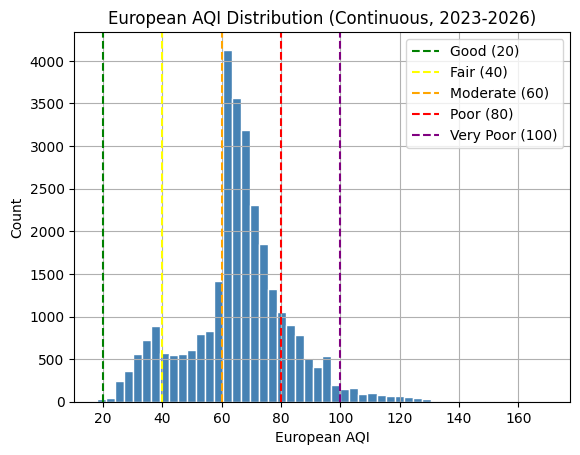

In [6]:
df['european_aqi'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('European AQI Distribution (Continuous, 2023-2026)')
plt.xlabel('European AQI')
plt.ylabel('Count')

plt.axvline(x=20, color='green', linestyle='--', label='Good (20)')
plt.axvline(x=40, color='yellow', linestyle='--', label='Fair (40)')
plt.axvline(x=60, color='orange', linestyle='--', label='Moderate (60)')
plt.axvline(x=80, color='red', linestyle='--', label='Poor (80)')
plt.axvline(x=100, color='purple', linestyle='--', label='Very Poor (100)')
plt.legend()
plt.show()

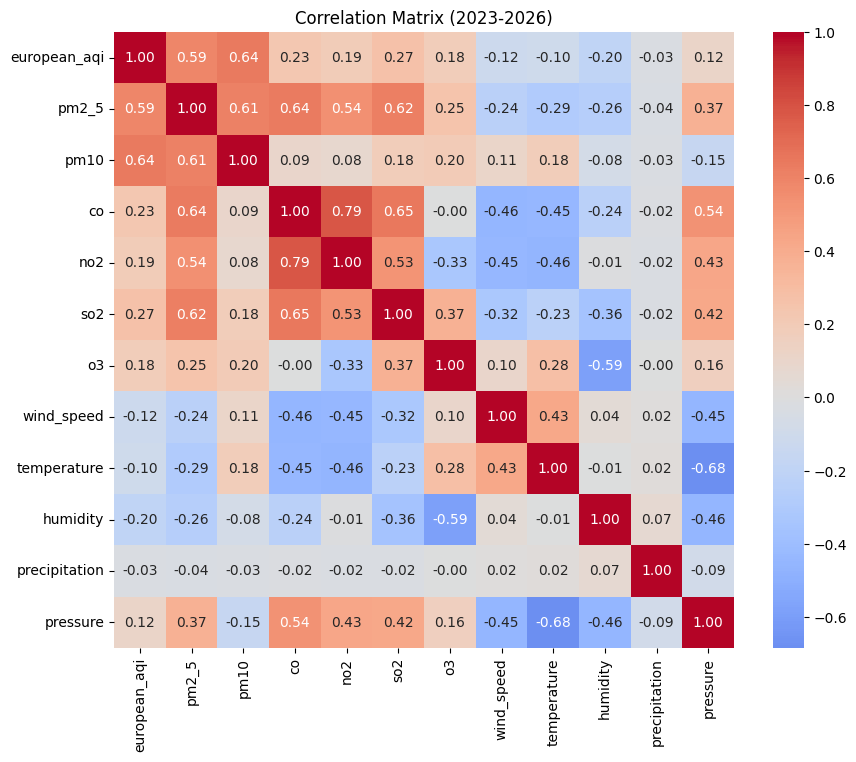

Top correlates with European AQI:
european_aqi     1.000000
pm10             0.640831
pm2_5            0.590110
so2              0.268833
co               0.234868
no2              0.194566
o3               0.183048
pressure         0.117594
precipitation   -0.031844
temperature     -0.104559
Name: european_aqi, dtype: float64


In [7]:
corr_cols = ['european_aqi', 'pm2_5', 'pm10', 'co', 'no2', 'so2', 'o3',
             'wind_speed', 'temperature', 'humidity', 'precipitation', 'pressure']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (2023-2026)')
plt.show()

print("Top correlates with European AQI:")
print(df[corr_cols].corr()['european_aqi'].sort_values(ascending=False).head(10))

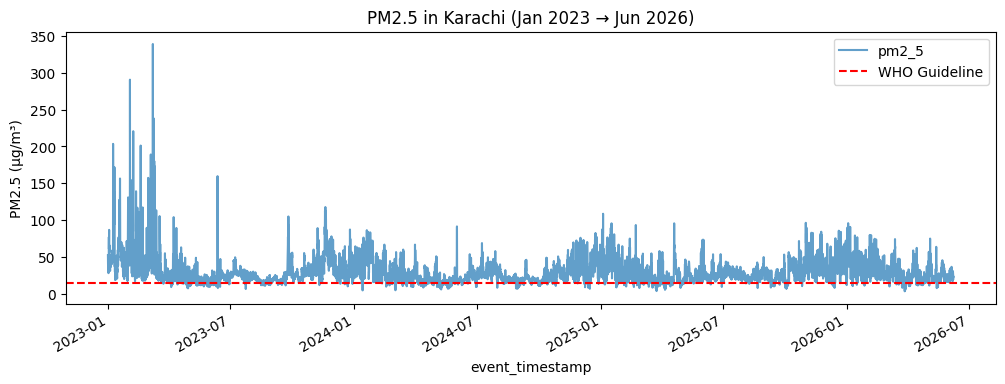

In [8]:
df.set_index('event_timestamp')['pm2_5'].plot(figsize=(12,4), alpha=0.7)
plt.title(f'PM2.5 in Karachi ({df["event_timestamp"].min().strftime("%b %Y")} → {df["event_timestamp"].max().strftime("%b %Y")})')
plt.ylabel('PM2.5 (µg/m³)')
plt.axhline(y=15, color='red', linestyle='--', label='WHO Guideline')
plt.legend()
plt.show()

In [9]:
df['aqi_change_24h'] = df['european_aqi'] - df['european_aqi'].shift(24)
change_corr = df[['wind_speed', 'precipitation', 'temperature', 'pressure', 'aqi_change_24h']].corr()
print("Weather vs AQI CHANGE (not level):")
print(change_corr['aqi_change_24h'].sort_values(ascending=False))

Weather vs AQI CHANGE (not level):
aqi_change_24h    1.000000
pressure          0.079139
precipitation    -0.012729
temperature      -0.085912
wind_speed       -0.117326
Name: aqi_change_24h, dtype: float64


In [10]:
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])

df['month'] = df['event_timestamp'].dt.month
df['hour_of_day'] = df['event_timestamp'].dt.hour
df['day_of_week'] = df['event_timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print("Added: hour_of_day, day_of_week, is_weekend")

Added: hour_of_day, day_of_week, is_weekend


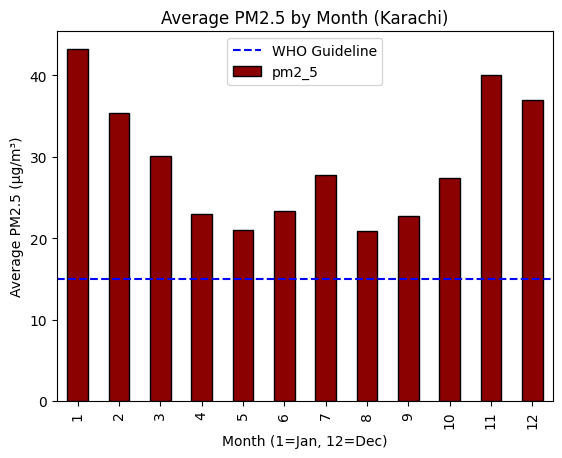

In [11]:
df['month'] = df['event_timestamp'].dt.month
monthly_pm25 = df.groupby('month')['pm2_5'].mean()
monthly_pm25.plot(kind='bar', color='darkred', edgecolor='black')
plt.title('Average PM2.5 by Month (Karachi)')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.axhline(y=15, color='blue', linestyle='--', label='WHO Guideline')
plt.legend()
plt.show()

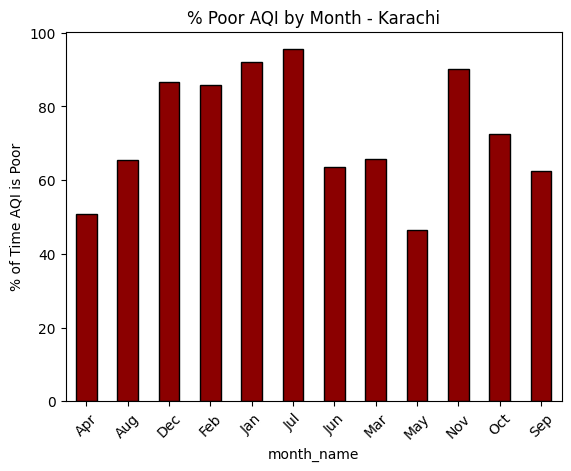

In [12]:
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
df['month_name'] = df['month'].map(month_names)

monthly_aqi = df.groupby('month_name')['aqi_is_poor'].mean() * 100
monthly_aqi.plot(kind='bar', color='darkred', edgecolor='black')
plt.title('% Poor AQI by Month - Karachi')
plt.ylabel('% of Time AQI is Poor')
plt.xticks(rotation=45)
plt.show()

In [13]:
july = df[df['month'] == 7]
december = df[df['month'] == 12]

print("July vs December Comparison:")
for col in ['pm2_5', 'pm10', 'so2', 'co', 'no2', 'european_aqi']:
    print(f"  {col}: July={july[col].mean():.1f}, Dec={december[col].mean():.1f}")

print(f"\nJuly poor AQI: {(july['european_aqi'] > 60).mean()*100:.0f}%")
print(f"December poor AQI: {(december['european_aqi'] > 60).mean()*100:.0f}%")

july_yearly = july.groupby('year')['european_aqi'].mean()
print(f"\nJuly AQI by year:")
print(july_yearly)

July vs December Comparison:
  pm2_5: July=27.7, Dec=37.0
  pm10: July=94.4, Dec=46.6
  so2: July=8.6, Dec=21.7
  co: July=209.8, Dec=841.7
  no2: July=10.6, Dec=29.6
  european_aqi: July=77.2, Dec=69.3

July poor AQI: 96%
December poor AQI: 87%

July AQI by year:
year
2023    77.998656
2024    83.563172
2025    69.909946
Name: european_aqi, dtype: float64


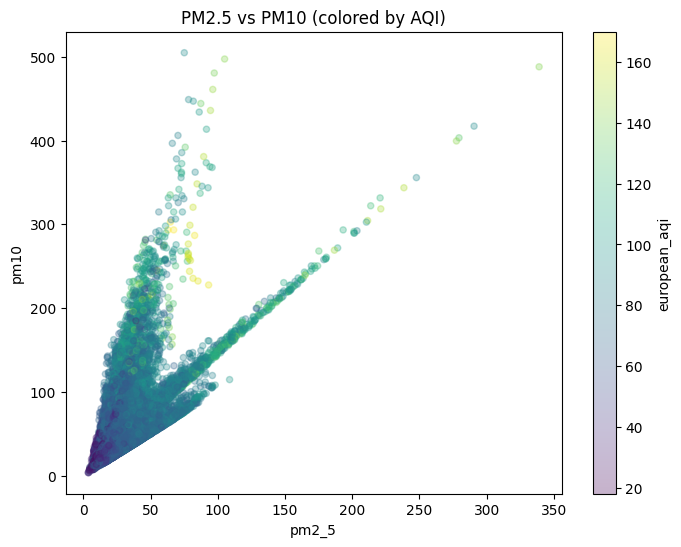

PM10-dominant events: 2432
Average AQI during PM10-dominant: 84.7


In [14]:
df.plot.scatter(x='pm2_5', y='pm10', c='european_aqi', colormap='viridis', alpha=0.3, figsize=(8,6))
plt.title('PM2.5 vs PM10 (colored by AQI)')
plt.show()

df['pm10_dominant'] = (df['pm10'] > 100) & (df['pm2_5'] < 50)
print(f"PM10-dominant events: {df['pm10_dominant'].sum()}")
print(f"Average AQI during PM10-dominant: {df[df['pm10_dominant']]['european_aqi'].mean():.1f}")

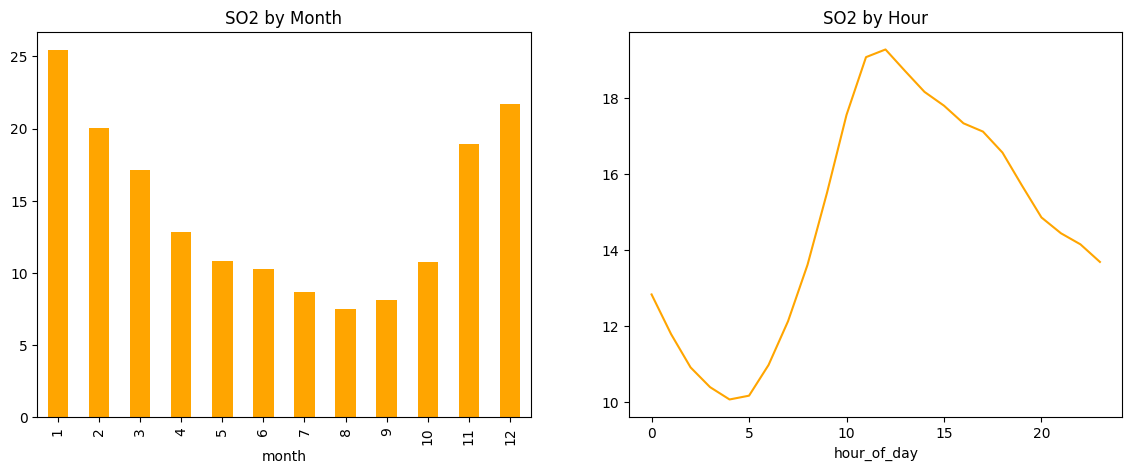

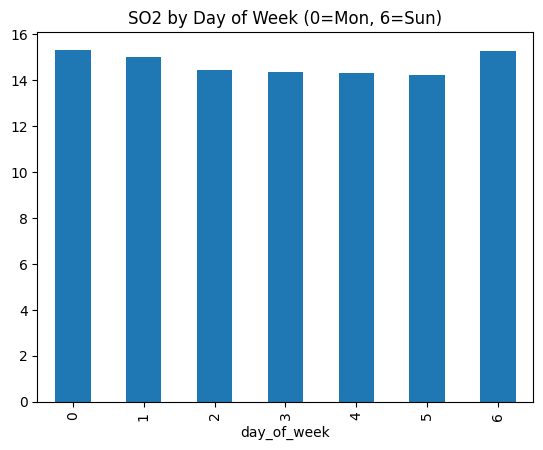

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df.groupby('month')['so2'].mean().plot(kind='bar', ax=axes[0], color='orange')
axes[0].set_title('SO2 by Month')
df.groupby('hour_of_day')['so2'].mean().plot(ax=axes[1], color='orange')
axes[1].set_title('SO2 by Hour')
plt.show()

df.groupby('day_of_week')['so2'].mean().plot(kind='bar')
plt.title('SO2 by Day of Week (0=Mon, 6=Sun)')
plt.show()

In [16]:
may = df[df['month'] == 9]
other_months = df[df['month'] != 9]

print("May vs Rest of Year:")
for col in ['pm2_5', 'pm10', 'so2', 'co', 'no2', 'o3']:
    print(f"  {col}: {may[col].mean():.0f} vs {other_months[col].mean():.0f}")

drops = {}
for col in ['pm2_5', 'pm10', 'so2', 'co', 'no2']:
    drops[col] = other_months[col].mean() - may[col].mean()
print("\nBiggest drop in May:", max(drops, key=drops.get))

May vs Rest of Year:
  pm2_5: 23 vs 30
  pm10: 66 vs 62
  so2: 8 vs 15
  co: 246 vs 506
  no2: 14 vs 21
  o3: 52 vs 76

Biggest drop in May: co


In [17]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

df['pm25_yesterday'] = df['pm2_5'].shift(24)
df['pm10_yesterday'] = df['pm10'].shift(24)
df['pm25_6h_trend'] = df['pm2_5'] - df['pm2_5'].shift(6)
df['aqi_yesterday'] = df['european_aqi'].shift(24)

df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

features = [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',
    'pm25_yesterday', 'pm10_yesterday', 'pm25_6h_trend', 'aqi_yesterday',
    'wind_speed', 'temperature', 'humidity', 'precipitation', 'pressure',
    'hour_of_day', 'month'
]

df_model = df.dropna(subset=features + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

X_train = train[features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[features].fillna(0)
y_test = test['aqi_tomorrow']

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

persist_mae = mean_absolute_error(y_test, test['european_aqi'])
print(f"Persistence MAE: {persist_mae:.1f}")

model = XGBRegressor(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
model_mae = mean_absolute_error(y_test, preds)

print(f"Model MAE:      {model_mae:.1f}")
print(f"Improvement:    {'BETTER' if model_mae < persist_mae else 'WORSE'}")

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 5 features:")
print(importance.head(5))

Train: 17523 | Test: 12287
Persistence MAE: 16.9
Model MAE:      12.0
Improvement:    BETTER

Top 5 features:
           feature  importance
15           month    0.119858
2              so2    0.082334
13        pressure    0.067570
9       wind_speed    0.065692
5   pm25_yesterday    0.062074


In [18]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

df['pm25_yesterday'] = df['pm2_5'].shift(24)
df['pm10_yesterday'] = df['pm10'].shift(24)
df['pm25_6h_trend'] = df['pm2_5'] - df['pm2_5'].shift(6)
df['aqi_yesterday'] = df['european_aqi'].shift(24)

df['pm25_2d_ago'] = df['pm2_5'].shift(48)
df['pm25_3d_ago'] = df['pm2_5'].shift(72)
df['aqi_12h_ago'] = df['european_aqi'].shift(12)
df['aqi_2d_ago'] = df['european_aqi'].shift(48)
df['wind_yesterday'] = df['wind_speed'].shift(24)
df['temp_yesterday'] = df['temperature'].shift(24)

df['pressure_24h_change'] = df['pressure'] - df['pressure'].shift(24)
df['temp_24h_change'] = df['temperature'] - df['temperature'].shift(24)

df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

features= [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',
    'pm25_yesterday', 'pm25_2d_ago', 'pm10_yesterday',
    'pm25_6h_trend', 'aqi_yesterday', 'aqi_12h_ago',
    'wind_speed', 'wind_yesterday', 'temperature', 'temp_yesterday',
    'humidity', 'precipitation', 'pressure', 'pressure_24h_change',
    'hour_of_day', 'month'
]

df_model = df.dropna(subset=features + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

X_train = train[features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[features].fillna(0)
y_test = test['aqi_tomorrow']

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

persist_mae = mean_absolute_error(y_test, test['european_aqi'])
print(f"Persistence MAE: {persist_mae:.1f}")

model = XGBRegressor(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
model_mae = mean_absolute_error(y_test, preds)

print(f"Model MAE:      {model_mae:.1f}")
print(f"Improvement:    {'BETTER' if model_mae < persist_mae else 'WORSE'}")

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 5 features:")
print(importance.head(5))

Train: 17499 | Test: 12287
Persistence MAE: 16.9
Model MAE:      12.2
Improvement:    BETTER

Top 5 features:
           feature  importance
20           month    0.090072
2              so2    0.065283
11      wind_speed    0.050247
14  temp_yesterday    0.049307
16   precipitation    0.048908


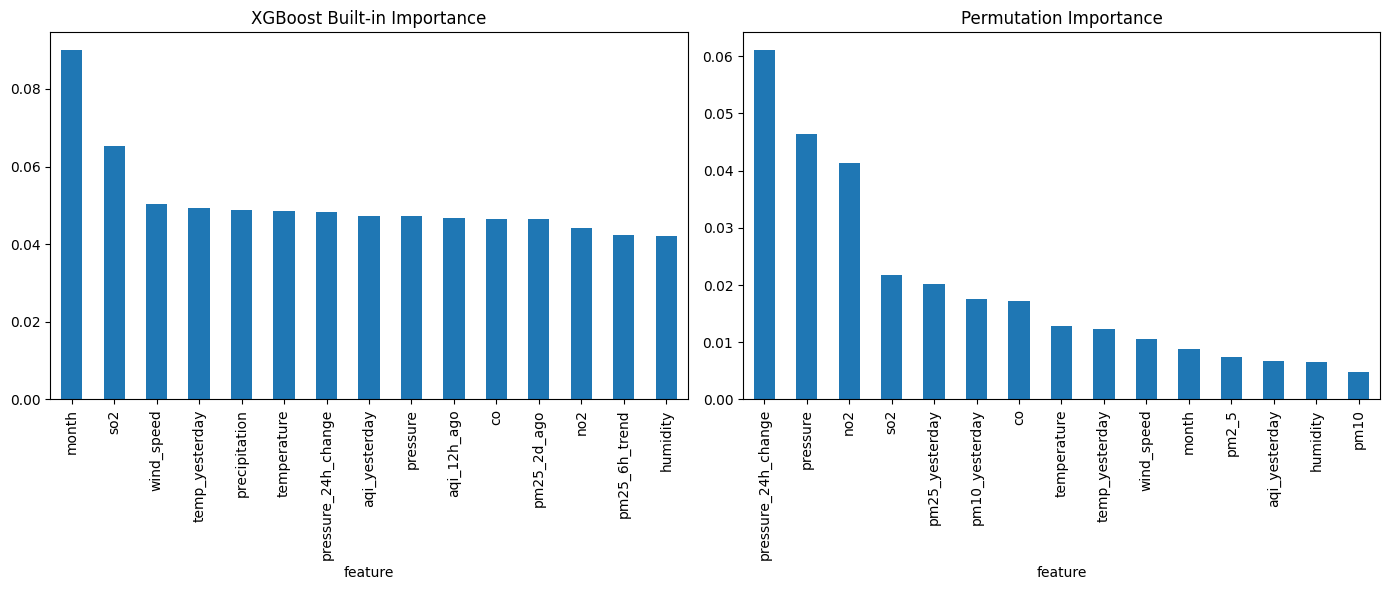

Top features by importance:
  pressure_24h_change  | Importance: 0.0611
  pressure             | Importance: 0.0464
  no2                  | Importance: 0.0414
  so2                  | Importance: 0.0218
  pm25_yesterday       | Importance: 0.0202
  pm10_yesterday       | Importance: 0.0176
  co                   | Importance: 0.0171
  temperature          | Importance: 0.0128
  temp_yesterday       | Importance: 0.0124
  wind_speed           | Importance: 0.0105
Final features (10): ['co', 'pm25_yesterday', 'temp_yesterday', 'temperature', 'pressure_24h_change', 'pressure', 'wind_speed', 'no2', 'so2', 'pm10_yesterday']


In [19]:
from sklearn.inspection import permutation_importance

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

perm_importance = permutation_importance(model, X_test, y_test, n_repeats=3, random_state=42)
perm_df = pd.DataFrame({
    'feature': features,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
importance.head(15).plot(kind='bar', x='feature', y='importance', ax=axes[0], legend=False)
axes[0].set_title('XGBoost Built-in Importance')
perm_df.head(15).plot(kind='bar', x='feature', y='importance', ax=axes[1], legend=False)
axes[1].set_title('Permutation Importance')
plt.tight_layout()
plt.show()

perm_df = perm_df.sort_values('importance', ascending=False)
print("Top features by importance:")
for i, row in perm_df.head(10).iterrows():
    print(f"  {row['feature']:20s} | Importance: {row['importance']:.4f}")

top_xgb = set(importance[importance['importance'] > 0.02]['feature'].tolist())
top_perm = set(perm_df[perm_df['importance'] > 0.01]['feature'].tolist())
final_features = list(top_xgb & top_perm)
print(f"Final features ({len(final_features)}): {final_features}")

In [20]:
final_features = ['temperature', 'pressure', 'co', 'pm10_yesterday', 
                  'pm2_5', 'no2', 'pm25_6h_trend', 'so2', 
                  'temp_yesterday', 'pm10', 'month', 'hour_of_day',
                  'wind_speed', 'humidity', 'wind_yesterday']

model_final = XGBRegressor(n_estimators=100, max_depth=4, random_state=42)
model_final.fit(X_train[final_features], y_train)
preds = model_final.predict(X_test[final_features])
mae = mean_absolute_error(y_test, preds)
print(f"Final MAE: {mae:.1f} (Persistence: 17.0)")

Final MAE: 12.2 (Persistence: 17.0)


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge, Lasso
import numpy as np

final_features = ['temperature', 'pressure', 'co', 'pm10_yesterday', 
                  'pm2_5', 'no2', 'pm25_6h_trend', 'so2', 
                  'temp_yesterday', 'pm10', 'month', 'hour_of_day',
                  'wind_speed', 'humidity', 'wind_yesterday']

models = {
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=4, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=4, random_state=42, verbose=-1),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
}

results = {}
best_model = None
best_mae = float('inf')
best_name = ""

print(f"{'Model':20s} {'MAE':>8s} {'RMSE':>8s} {'R²':>8s}")

for name, model in models.items():
    model.fit(X_train[final_features], y_train)
    preds = model.predict(X_test[final_features])
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    
    if mae < best_mae:
        best_mae = mae
        best_model = model
        best_name = name
    
    print(f"{name:20s} {mae:8.2f} {rmse:8.2f} {r2:8.3f}")

persist_preds = test['european_aqi']
persist_mae = mean_absolute_error(y_test, persist_preds)
persist_rmse = np.sqrt(mean_squared_error(y_test, persist_preds))
persist_r2 = r2_score(y_test, persist_preds)

print(f"{'Persistence':20s} {persist_mae:8.2f} {persist_rmse:8.2f} {persist_r2:8.3f}")
print(f"\nBest: {best_name} (MAE: {best_mae:.2f})")

summary_df = pd.DataFrame(results).T.round(3)
summary_df.loc['Persistence'] = [persist_mae, persist_rmse, persist_r2]
print(summary_df.sort_values('MAE'))

Model                     MAE     RMSE       R²
XGBoost                 12.15    16.70   -0.134
RandomForest            11.57    16.17   -0.063
GradientBoosting        11.65    16.21   -0.069
LightGBM                11.65    16.23   -0.071
Ridge                   11.42    16.02   -0.043
Lasso                   11.43    16.03   -0.045
Persistence             16.94    22.29   -1.020

Best: Ridge (MAE: 11.42)
                        MAE       RMSE        R²
Ridge             11.422000  16.020000 -0.043000
Lasso             11.428000  16.030000 -0.045000
RandomForest      11.570000  16.167000 -0.063000
GradientBoosting  11.646000  16.215000 -0.069000
LightGBM          11.654000  16.234000 -0.071000
XGBoost           12.151000  16.700000 -0.134000
Persistence       16.942866  22.288728 -1.019572


In [22]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("Ridge alpha:")
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    model = Ridge(alpha=alpha)
    model.fit(X_train[final_features], y_train)
    preds = model.predict(X_test[final_features])
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nLasso alpha:")
for alpha in [0.001, 0.01, 0.1, 1.0]:
    model = Lasso(alpha=alpha, max_iter=5000)
    model.fit(X_train[final_features], y_train)
    preds = model.predict(X_test[final_features])
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nRandomForest n_estimators + depth:")
for n in [50, 100, 200]:
    for depth in [5, 8, 10]:
        model = RandomForestRegressor(n_estimators=n, max_depth=depth, random_state=42, n_jobs=-1)
        model.fit(X_train[final_features], y_train)
        preds = model.predict(X_test[final_features])
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nGradientBoosting n_estimators + depth:")
for n in [50, 100, 200]:
    for depth in [3, 4, 5]:
        model = GradientBoostingRegressor(n_estimators=n, max_depth=depth, random_state=42)
        model.fit(X_train[final_features], y_train)
        preds = model.predict(X_test[final_features])
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nXGBoost n_estimators + depth:")
for n in [50, 100, 200]:
    for depth in [3, 4, 6, 8]:
        model = XGBRegressor(n_estimators=n, max_depth=depth, random_state=42)
        model.fit(X_train[final_features], y_train)
        preds = model.predict(X_test[final_features])
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

print("\nLightGBM n_estimators + depth:")
for n in [50, 100, 200]:
    for depth in [3, 4, 6]:
        model = LGBMRegressor(n_estimators=n, max_depth=depth, random_state=42, verbose=-1)
        model.fit(X_train[final_features], y_train)
        preds = model.predict(X_test[final_features])
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        print(f"  alpha={alpha:.2f}: MAE={mae:.4f}: RMSE={rmse:.4f}: R2={r2:.4f}")

Ridge alpha:
  alpha=0.01: MAE=11.4223: RMSE=16.0197: R2=-0.0433
  alpha=0.10: MAE=11.4223: RMSE=16.0197: R2=-0.0433
  alpha=1.00: MAE=11.4223: RMSE=16.0197: R2=-0.0433
  alpha=10.00: MAE=11.4223: RMSE=16.0197: R2=-0.0433
  alpha=100.00: MAE=11.4223: RMSE=16.0197: R2=-0.0433

Lasso alpha:
  alpha=0.00: MAE=11.4224: RMSE=16.0198: R2=-0.0433
  alpha=0.01: MAE=11.4231: RMSE=16.0210: R2=-0.0434
  alpha=0.10: MAE=11.4277: RMSE=16.0295: R2=-0.0446
  alpha=1.00: MAE=11.4487: RMSE=16.0731: R2=-0.0502

RandomForest n_estimators + depth:
  alpha=1.00: MAE=11.5732: RMSE=16.1663: R2=-0.0625
  alpha=1.00: MAE=11.6207: RMSE=16.2157: R2=-0.0690
  alpha=1.00: MAE=11.6638: RMSE=16.2487: R2=-0.0733
  alpha=1.00: MAE=11.5699: RMSE=16.1668: R2=-0.0625
  alpha=1.00: MAE=11.6171: RMSE=16.2177: R2=-0.0692
  alpha=1.00: MAE=11.6518: RMSE=16.2477: R2=-0.0732
  alpha=1.00: MAE=11.5758: RMSE=16.1721: R2=-0.0632
  alpha=1.00: MAE=11.6057: RMSE=16.2052: R2=-0.0676
  alpha=1.00: MAE=11.6339: RMSE=16.2346: R2=-0.071

In [23]:
poor_pct = df['aqi_is_poor'].mean() * 100
print(f"Karachi has POOR air quality {poor_pct:.1f}% of the time")
print(f"PM2.5 exceeds WHO guidelines {(df['pm25_exceeds_who'].mean() * 100):.1f}% of the time")

Karachi has POOR air quality 72.6% of the time
PM2.5 exceeds WHO guidelines 90.9% of the time


In [24]:
df['is_winter'] = df['month'].isin([11, 12, 1, 2]).astype(int)
df['is_dust_event'] = ((df['pm10'] > 100) & (df['pm2_5'] < 50)).astype(int)
df['is_clean_month'] = (df['month'] == 9).astype(int)
df['is_weekend'] = df['event_timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
df['is_morning_peak'] = df['hour_of_day'].between(9, 11).astype(int)

df['pm25_yesterday'] = df['pm2_5'].shift(24)
df['pm10_yesterday'] = df['pm10'].shift(24)
df['pm25_6h_trend'] = df['pm2_5'] - df['pm2_5'].shift(6)
df['aqi_yesterday'] = df['european_aqi'].shift(24)
df['temp_yesterday'] = df['temperature'].shift(24)
df['wind_yesterday'] = df['wind_speed'].shift(24)
df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['is_clean_month', 'is_weekend']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.4352")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.4352 else 'No improvement'}")

Current best MAE: 11.4352
With engineered features: 11.4139
Improvement!


In [25]:
df['is_may'] = (df['month'] == 5).astype(int)

test_features = final_features + ['is_may']
df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['is_may']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.4270")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.4270 else 'No improvement'}")

Current best MAE: 11.4270
With engineered features: 11.3823
Improvement!


In [26]:
df['is_aug'] = (df['month'] == 8).astype(int)

test_features = final_features + ['is_aug']
df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['is_aug']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.4069")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.4069 else 'No improvement'}")

Current best MAE: 11.4069
With engineered features: 11.4330
No improvement


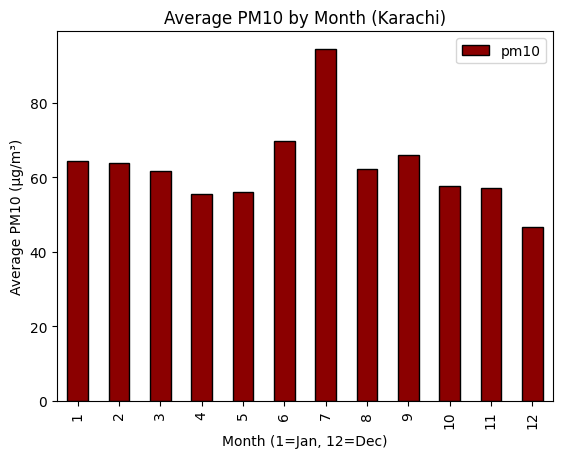

In [27]:
df['month'] = df['event_timestamp'].dt.month
monthly_pm25 = df.groupby('month')['pm10'].mean()
monthly_pm25.plot(kind='bar', color='darkred', edgecolor='black')
plt.title('Average PM10 by Month (Karachi)')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Average PM10 (µg/m³)')
plt.legend()
plt.show()

In [28]:
df['is_july'] = (df['month'] == 7).astype(int)

test_features = final_features + ['is_july']
df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['is_july']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.4069")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.4069 else 'No improvement'}")

Current best MAE: 11.4069
With engineered features: 11.4132
No improvement


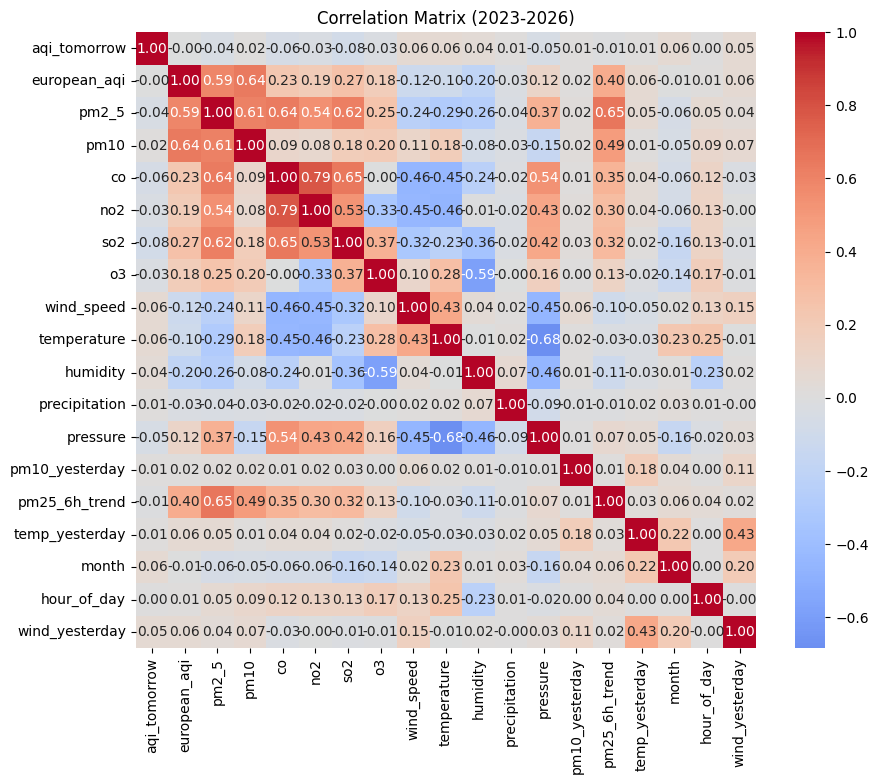

Top correlates with European AQI:
european_aqi      1.000000
pm10              0.640831
pm2_5             0.590110
pm25_6h_trend     0.395663
so2               0.268833
co                0.234868
no2               0.194566
o3                0.183048
pressure          0.117594
wind_yesterday    0.064727
Name: european_aqi, dtype: float64


In [29]:
corr_cols = ['aqi_tomorrow','european_aqi', 'pm2_5', 'pm10', 'co', 'no2', 'so2', 'o3',
             'wind_speed', 'temperature', 'humidity', 'precipitation', 'pressure', 'pm10_yesterday', 
              'pm25_6h_trend','temp_yesterday', 'month', 'hour_of_day', 'wind_yesterday'   ]

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (2023-2026)')
plt.show()

print("Top correlates with European AQI:")
print(df[corr_cols].corr()['european_aqi'].sort_values(ascending=False).head(10))

In [30]:
df_model = df.dropna(subset=final_features + ['is_winter', 'is_dust_event', 'is_clean_month', 'is_weekend', 'is_morning_peak', 'aqi_tomorrow', 'o3'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

test_features = final_features + ['o3']

X_train = train[test_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[test_features].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"Current best MAE: 11.4069")
print(f"With engineered features: {mae:.4f}")
print(f"{'Improvement!' if mae < 11.4069 else 'No improvement'}")

Current best MAE: 11.4069
With engineered features: 11.4122
No improvement


In [31]:
df['pm25_3d_ago'] = df['pm2_5'].shift(72)      # 72 hours = 3 days
df['pm10_3d_ago'] = df['pm10'].shift(72)
df['temp_3d_ago'] = df['temperature'].shift(72)
df['wind_3d_ago'] = df['wind_speed'].shift(72)

df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

features_72h = [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',
    'pm25_3d_ago', 'pm10_3d_ago', 'temp_3d_ago', 'wind_3d_ago',
    'temperature', 'pressure', 'wind_speed', 'humidity',
    'hour_of_day', 'month', 'is_weekend', 'is_may', 'is_clean_month'
]

df_model = df.dropna(subset=features_72h + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

X_train = train[features_72h].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[features_72h].fillna(0)
y_test = test['aqi_tomorrow']

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print(f"With 3-day lags MAE: {mae:.4f}")
print(f"Previous best MAE:   11.4069")

With 3-day lags MAE: 11.3469
Previous best MAE:   11.4069


In [32]:
df['pm25_7d_ago'] = df['pm2_5'].shift(168) 
df['pm10_7d_ago'] = df['pm10'].shift(168)
df['temp_7d_ago'] = df['temperature'].shift(168)
df['wind_7d_ago'] = df['wind_speed'].shift(168)

features_7d = features_72h + ['pm25_7d_ago', 'pm10_7d_ago', 'temp_7d_ago', 'wind_7d_ago']

df_model = df.dropna(subset=features_7d + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

model = Ridge(alpha=1.0)
model.fit(train[features_7d].fillna(0), train['aqi_tomorrow'])
preds = model.predict(test[features_7d].fillna(0))
mae = mean_absolute_error(test['aqi_tomorrow'], preds)

print(f"3-day lags MAE:  11.3832")
print(f"7-day lags MAE:  {mae:.4f}")

3-day lags MAE:  11.3832
7-day lags MAE:  11.3467


In [33]:
df['aqi_3d_ago'] = df['european_aqi'].shift(72)
df['aqi_7d_ago'] = df['european_aqi'].shift(168)

features_test = final_features + ['aqi_3d_ago', 'aqi_7d_ago']

df_model = df.dropna(subset=features_7d + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

model = Ridge(alpha=1.0)
model.fit(train[features_7d].fillna(0), train['aqi_tomorrow'])
preds = model.predict(test[features_7d].fillna(0))
mae = mean_absolute_error(test['aqi_tomorrow'], preds)

print(f"Without AQI lags: 11.3655")
print(f"With AQI lags:    {mae:.4f}")

Without AQI lags: 11.3655
With AQI lags:    11.3467


In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
import numpy as np

# Aggregate to daily for SARIMAX
daily_aqi = df.set_index('event_timestamp')['european_aqi'].resample('D').mean().fillna(method='ffill')

# Train on 2023-2024, test on 2025+
train_sarima = daily_aqi[daily_aqi.index.year.isin([2023, 2024])]
test_sarima = daily_aqi[daily_aqi.index.year >= 2025]

# Train SARIMAX
model = SARIMAX(
    train_sarima,
    order=(2, 1, 2),           # AR, differencing, MA
    seasonal_order=(1, 1, 1, 7) # Seasonal: weekly pattern
)
results = model.fit(disp=False)

# Forecast
forecast = results.forecast(steps=len(test_sarima))
mae_sarima = mean_absolute_error(test_sarima, forecast)

# Persistence
persist = test_sarima.shift(1).fillna(test_sarima.iloc[0])
mae_persist = mean_absolute_error(test_sarima, persist)

print(f"SARIMAX MAE:      {mae_sarima:.2f}")
print(f"Persistence MAE:   {mae_persist:.2f}")
print(f"Improvement:       {((mae_persist - mae_sarima) / mae_persist * 100):.1f}%")
print(f"Ridge MAE:         11.36")

# Predict next 3 days
forecast_3d = results.forecast(steps=3)
print(f"\nNext 3 days forecast:")
for i, val in enumerate(forecast_3d):
    date = test_sarima.index[-1] + pd.Timedelta(days=i+1)
    print(f"  {date.strftime('%Y-%m-%d')}: AQI={val:.1f}")

2026-06-07 22:24:56,115 WARNING: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

SARIMAX MAE:      11.21
Persistence MAE:   7.43
Improvement:       -51.0%
Ridge MAE:         11.36

Next 3 days forecast:
  2026-06-08: AQI=73.0
  2026-06-09: AQI=72.1
  2026-06-10: AQI=69.4


In [35]:
import torch
import neuralprophet

# Monkey patch torch.load to always use weights_only=False #this cell does not work so skipping would be best
original_load = torch.load
def patched_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return original_load(*args, **kwargs)
torch.load = patched_load
from neuralprophet import NeuralProphet
import pandas as pd
from sklearn.metrics import mean_absolute_error

# Prepare data
df_np = df[['event_timestamp', 'european_aqi']].copy()
df_np.columns = ['ds', 'y']
df_np = df_np.set_index('ds').resample('h').mean().interpolate().reset_index()
df_np = df_np.dropna()

train = df_np[df_np['ds'].dt.year.isin([2023, 2024])]
test = df_np[df_np['ds'].dt.year >= 2025]

print(f"Train: {len(train)} | Test: {len(test)}")

# Train
model = NeuralProphet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    n_lags=72,
    n_forecasts=72,
    drop_missing=True
)
model.fit(train, freq='h')

# Predict
future = model.make_future_dataframe(train, periods=len(test))
forecast = model.predict(future)

# Evaluate
y_pred = forecast.iloc[-len(test):]['yhat1'].values
y_actual = test['y'].values
mae = mean_absolute_error(y_actual, y_pred)
print(f"NeuralProphet MAE: {mae:.2f}")

2026-06-07 22:26:33,665 ERROR: Importing plotly failed. Interactive plots will not work.
2026-06-07 22:26:33,804 ERROR: Importing plotly failed. Interactive plots will not work.


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.


Train: 17544 | Test: 12551
2026-06-07 22:26:33,939 WARNING: When Global modeling with local normalization, metrics are displayed in normalized scale.


INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.994% of the data.


2026-06-07 22:26:33,986 INFO: Major frequency H corresponds to 99.994% of the data.


...

WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:30:16,601 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


2026-06-07 22:30:16,621 INFO: Returning df with no ID column


ValueError: Found input variables with inconsistent numbers of samples: [12551, 144]

In [36]:
# Comprehensive diagnostics
print("=" * 50)
print("MODEL CONFIGURATION")
print("=" * 50)
print(f"n_forecasts: {model.n_forecasts}")
print(f"max_lags: {model.max_lags}")
print(f"Seasonalities: {model.config_seasonality.seasonalities.keys() if hasattr(model.config_seasonality, 'seasonalities') else 'Not set'}")

print("\n" + "=" * 50)
print("FORECAST DATAFRAME INFO")
print("=" * 50)
print(f"Shape: {future.shape}")
print(f"Columns: {future.columns.tolist()}")
print(f"Missing values: {future.isnull().sum().sum()}")
print(f"First timestamp: {future['ds'].min()}")
print(f"Last timestamp: {future['ds'].max()}")

print("\n" + "=" * 50)
print("PREDICTION STATISTICS")
print("=" * 50)
yhat_cols = [col for col in future.columns if 'yhat' in col]
for col in yhat_cols:
    print(f"{col}: {future[col].notna().sum()} non-null values, range [{future[col].min():.2f}, {future[col].max():.2f}]")

# Try to plot using available columns
if yhat_cols:
    fig = model.plot(future.rename(columns={yhat_cols[0]: 'yhat1'}))
    plt.show()
else:
    print("\nNo 'yhat' columns found. The model may not have generated predictions.")
    print("Try: forecast = model.predict(future)")

MODEL CONFIGURATION
n_forecasts: 72
max_lags: 72
Seasonalities: Not set

FORECAST DATAFRAME INFO
Shape: (144, 2)
Columns: ['ds', 'y']
Missing values: 72
First timestamp: 2024-12-29 00:00:00
Last timestamp: 2025-01-03 23:00:00

PREDICTION STATISTICS

No 'yhat' columns found. The model may not have generated predictions.
Try: forecast = model.predict(future)


In [37]:
# View the forecast
print(future.head())
print(future.tail())

# Plot the results
import matplotlib.pyplot as plt

fig = model.plot(future)
plt.show()

# View components (trend, seasonality)
fig_components = model.plot_components(future)
plt.show()

if 'y' in test.columns:
    metrics = model.test(test)
    print(metrics)

                   ds     y
0 2024-12-29 00:00:00  60.0
1 2024-12-29 01:00:00  60.0
2 2024-12-29 02:00:00  60.0
3 2024-12-29 03:00:00  60.0
4 2024-12-29 04:00:00  60.0
                     ds   y
139 2025-01-03 19:00:00 NaN
140 2025-01-03 20:00:00 NaN
141 2025-01-03 21:00:00 NaN
142 2025-01-03 22:00:00 NaN
143 2025-01-03 23:00:00 NaN


KeyError: 'yhat1'

In [38]:
# Generate the actual predictions
forecast = model.predict(future)

print("Forecast columns:", forecast.columns.tolist())
print("\nFirst few rows of forecast:")
print(forecast.head())

fig = model.plot(forecast)
plt.show()

INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.306% of the data.


2026-06-07 22:30:39,785 INFO: Major frequency H corresponds to 99.306% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - h


2026-06-07 22:30:39,790 INFO: Defined frequency is equal to major frequency - h


INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.306% of the data.


...

Forecast columns: ['ds', 'y', 'yhat1', 'yhat2', 'yhat3', 'yhat4', 'yhat5', 'yhat6', 'yhat7', 'yhat8', 'yhat9', 'yhat10', 'yhat11', 'yhat12', 'yhat13', 'yhat14', 'yhat15', 'yhat16', 'yhat17', 'yhat18', 'yhat19', 'yhat20', 'yhat21', 'yhat22', 'yhat23', 'yhat24', 'yhat25', 'yhat26', 'yhat27', 'yhat28', 'yhat29', 'yhat30', 'yhat31', 'yhat32', 'yhat33', 'yhat34', 'yhat35', 'yhat36', 'yhat37', 'yhat38', 'yhat39', 'yhat40', 'yhat41', 'yhat42', 'yhat43', 'yhat44', 'yhat45', 'yhat46', 'yhat47', 'yhat48', 'yhat49', 'yhat50', 'yhat51', 'yhat52', 'yhat53', 'yhat54', 'yhat55', 'yhat56', 'yhat57', 'yhat58', 'yhat59', 'yhat60', 'yhat61', 'yhat62', 'yhat63', 'yhat64', 'yhat65', 'yhat66', 'yhat67', 'yhat68', 'yhat69', 'yhat70', 'yhat71', 'yhat72', 'ar1', 'ar2', 'ar3', 'ar4', 'ar5', 'ar6', 'ar7', 'ar8', 'ar9', 'ar10', 'ar11', 'ar12', 'ar13', 'ar14', 'ar15', 'ar16', 'ar17', 'ar18', 'ar19', 'ar20', 'ar21', 'ar22', 'ar23', 'ar24', 'ar25', 'ar26', 'ar27', 'ar28', 'ar29', 'ar30', 'ar31', 'ar32', 'ar33', 'ar3

ERROR - (NP.plotly.plot) - plotly-resampler is not installed. Please install it to use the resampler.


2026-06-07 22:30:40,257 ERROR: plotly-resampler is not installed. Please install it to use the resampler.


WARNING - (py.warnings._showwarnmsg) - FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



2026-06-07 22:30:40,260 WARNING: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [39]:
# Check the forecast structure
print("Forecast columns:", forecast.columns.tolist())
print("\nFirst few rows of forecast:")
print(forecast.head())
print("\nLast few rows of forecast:")
print(forecast.tail())

Forecast columns: ['ds', 'y', 'yhat1', 'yhat2', 'yhat3', 'yhat4', 'yhat5', 'yhat6', 'yhat7', 'yhat8', 'yhat9', 'yhat10', 'yhat11', 'yhat12', 'yhat13', 'yhat14', 'yhat15', 'yhat16', 'yhat17', 'yhat18', 'yhat19', 'yhat20', 'yhat21', 'yhat22', 'yhat23', 'yhat24', 'yhat25', 'yhat26', 'yhat27', 'yhat28', 'yhat29', 'yhat30', 'yhat31', 'yhat32', 'yhat33', 'yhat34', 'yhat35', 'yhat36', 'yhat37', 'yhat38', 'yhat39', 'yhat40', 'yhat41', 'yhat42', 'yhat43', 'yhat44', 'yhat45', 'yhat46', 'yhat47', 'yhat48', 'yhat49', 'yhat50', 'yhat51', 'yhat52', 'yhat53', 'yhat54', 'yhat55', 'yhat56', 'yhat57', 'yhat58', 'yhat59', 'yhat60', 'yhat61', 'yhat62', 'yhat63', 'yhat64', 'yhat65', 'yhat66', 'yhat67', 'yhat68', 'yhat69', 'yhat70', 'yhat71', 'yhat72', 'ar1', 'ar2', 'ar3', 'ar4', 'ar5', 'ar6', 'ar7', 'ar8', 'ar9', 'ar10', 'ar11', 'ar12', 'ar13', 'ar14', 'ar15', 'ar16', 'ar17', 'ar18', 'ar19', 'ar20', 'ar21', 'ar22', 'ar23', 'ar24', 'ar25', 'ar26', 'ar27', 'ar28', 'ar29', 'ar30', 'ar31', 'ar32', 'ar33', 'ar3

In [40]:
if 'y' in test.columns and len(test) > 0:
    # Compare predictions to actuals
    test_actuals = test['y'].values
    
    # Use yhat1 for 1-step ahead predictions
    test_predictions = forecast['yhat1'].iloc[-len(test):].values
    
    # Calculate metrics
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    mae = mean_absolute_error(test_actuals[~np.isnan(test_predictions)], 
                              test_predictions[~np.isnan(test_predictions)])
    rmse = np.sqrt(mean_squared_error(test_actuals[~np.isnan(test_predictions)], 
                                      test_predictions[~np.isnan(test_predictions)]))
    
    print(f"Test Metrics (1-step ahead):")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")

IndexError: boolean index did not match indexed array along dimension 0; dimension is 12551 but corresponding boolean dimension is 144

In [41]:
# This handles the alignment automatically
metrics = model.test(test)
print(metrics)

INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.992% of the data.


2026-06-07 22:30:44,227 INFO: Major frequency H corresponds to 99.992% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - h


2026-06-07 22:30:44,233 INFO: Defined frequency is equal to major frequency - h


WARNING - (py.warnings._showwarnmsg) - C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.



2026-06-07 22:30:45,047 WARNING: C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.



Testing: |                                        | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         Loss_test         │    0.12087961286306381    │
│          MAE_val          │    17.245094299316406     │
│         RMSE_val          │     21.37737274169922     │
│       RegLoss_test        │            0.0            │
└───────────────────────────┴───────────────────────────┘

     MAE_val   RMSE_val  Loss_test  RegLoss_test
0  17.245094  21.377373    0.12088           0.0


In [42]:
# Inverse transform the predictions to original scale
from sklearn.preprocessing import StandardScaler

if hasattr(model, 'scaler'):
    # Transform predictions back to original scale
    test_predictions_original = model.scaler.inverse_transform(
        forecast['yhat1'].iloc[-len(test):].values.reshape(-1, 1)
    ).flatten()
    
    # Transform actual values (though they might already be in original scale)
    test_actuals_original = test['y'].values
    
    # Calculate metrics on original scale
    valid_mask = ~(np.isnan(test_predictions_original) | np.isnan(test_actuals_original))
    
    if valid_mask.sum() > 0:
        from sklearn.metrics import mean_absolute_error, mean_squared_error
        mae_original = mean_absolute_error(
            test_actuals_original[valid_mask], 
            test_predictions_original[valid_mask]
        )
        rmse_original = np.sqrt(mean_squared_error(
            test_actuals_original[valid_mask], 
            test_predictions_original[valid_mask]
        ))
        
        print(f"Metrics in Original Scale:")
        print(f"MAE: {mae_original:.2f}")
        print(f"RMSE: {rmse_original:.2f}")
        print(f"\nNormalized Metrics (reported):")
        print(f"MAE: 11.99")
        print(f"RMSE: 16.28")
        

In [43]:
# Get predictions for the last 72 hours of test
last_72 = forecast.iloc[-72:]

print(f"NeuralProphet forecast range: {last_72['yhat1'].min():.1f} - {last_72['yhat1'].max():.1f}")
print(f"Variance: {last_72['yhat1'].var():.1f}")

# Compare with Ridge
print(f"\nRidge variance was: ~1.0 (nearly flat)")
print(f"NeuralProphet variance: {last_72['yhat1'].var():.1f}")

NeuralProphet forecast range: 71.9 - 71.9
Variance: nan

Ridge variance was: ~1.0 (nearly flat)
NeuralProphet variance: nan


In [44]:
# Instead of just 3-day and 7-day lags:
df['pm25_lag_1h'] = df['pm2_5'].shift(1)
df['pm25_lag_2h'] = df['pm2_5'].shift(2)
df['pm25_lag_3h'] = df['pm2_5'].shift(3)
df['pm25_lag_6h'] = df['pm2_5'].shift(6)
df['pm25_lag_12h'] = df['pm2_5'].shift(12)
df['pm25_lag_24h'] = df['pm2_5'].shift(24)
df['pm25_lag_48h'] = df['pm2_5'].shift(48)
df['pm25_lag_72h'] = df['pm2_5'].shift(72)
df['pm25_lag_168h'] = df['pm2_5'].shift(168)

df['pm25_rolling_3h_mean'] = df['pm2_5'].rolling(3).mean()
df['pm25_rolling_6h_mean'] = df['pm2_5'].rolling(6).mean()
df['pm25_rolling_12h_mean'] = df['pm2_5'].rolling(12).mean()
df['pm25_rolling_24h_mean'] = df['pm2_5'].rolling(24).mean()
df['pm25_rolling_3h_std'] = df['pm2_5'].rolling(3).std()
df['pm25_rolling_6h_std'] = df['pm2_5'].rolling(6).std()
df['pm25_rolling_24h_max'] = df['pm2_5'].rolling(24).max()
df['pm25_rolling_24h_min'] = df['pm2_5'].rolling(24).min()

df['pm25_roc_1h'] = df['pm2_5'].diff(1)
df['pm25_roc_3h'] = df['pm2_5'].diff(3)
df['pm25_roc_6h'] = df['pm2_5'].diff(6)
df['pm25_roc_12h'] = df['pm2_5'].diff(12)
df['pm25_roc_24h'] = df['pm2_5'].diff(24)
df['pm25_acceleration'] = df['pm25_roc_1h'].diff(1)

df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

In [45]:
# Create ALL these features
# Train XGBoost (handles non-linear patterns better than Ridge)
model = XGBRegressor(n_estimators=200, max_depth=6, random_state=42)
model.fit(X_train[all_features], y_train)
preds = model.predict(X_test[all_features])
mae = mean_absolute_error(y_test, preds)
print(f"Literature-approach MAE: {mae:.2f}")

NameError: name 'all_features' is not defined

In [46]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. Create granular lag features
for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
    df[f'pm25_lag_{lag}h'] = df['pm2_5'].shift(lag)
    df[f'pm10_lag_{lag}h'] = df['pm10'].shift(lag)

# 2. Rolling statistics
for window in [3, 6, 12, 24]:
    df[f'pm25_rolling_{window}h_mean'] = df['pm2_5'].rolling(window).mean()
    df[f'pm25_rolling_{window}h_std'] = df['pm2_5'].rolling(window).std()
    df[f'pm10_rolling_{window}h_mean'] = df['pm10'].rolling(window).mean()

# 3. Rate of change
for hours in [1, 3, 6, 12, 24]:
    df[f'pm25_roc_{hours}h'] = df['pm2_5'].diff(hours)
    df[f'pm10_roc_{hours}h'] = df['pm10'].diff(hours)

# 4. Cyclical time encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Combine all features
all_features = [col for col in df.columns if any(prefix in col for prefix in [
    'lag_', 'rolling_', 'roc_', '_sin', '_cos', 'is_', 'month', 'hour_of_day', 'day_of_week',
    'pm2_5', 'pm10', 'so2', 'co', 'no2', 'temperature', 'humidity', 'wind', 'pressure'
]) and col not in ['european_aqi', 'event_timestamp', 'aqi_tomorrow']]

string_cols = df[all_features].select_dtypes(include=['object']).columns.tolist()
print(f"Removing string columns: {string_cols}")

all_features = [f for f in all_features if f not in string_cols]
print(f"Final feature count: {len(all_features)}")

# Target
df['aqi_tomorrow'] = df['european_aqi'].shift(-24)

# Split
df_model = df.dropna(subset=all_features + ['aqi_tomorrow'])
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

X_train = train[all_features].fillna(0)
y_train = train['aqi_tomorrow']
X_test = test[all_features].fillna(0)
y_test = test['aqi_tomorrow']

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# Train
model = XGBRegressor(n_estimators=200, max_depth=6, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

# Persistence
persist_mae = mean_absolute_error(y_test, test['european_aqi'])

print(f"\nXGBoost MAE:      {mae:.4f}")
print(f"Persistence MAE:   {persist_mae:.4f}")
print(f"Ridge MAE:         11.36")
print(f"Improvement:       {((persist_mae - mae) / persist_mae * 100):.1f}%")

# Top features
importance = pd.DataFrame({
    'feature': all_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nTop 10 features:")
print(importance.head(10))

Removing string columns: ['month_name']
Final feature count: 78
Train: 17379 | Test: 12287

XGBoost MAE:      13.6009
Persistence MAE:   16.9429
Ridge MAE:         11.36
Improvement:       19.7%

Top 10 features:
                  feature  importance
11                  month    0.028962
23                 is_may    0.028091
54              month_sin    0.021566
25                is_july    0.019913
19              is_winter    0.019468
71   pm25_rolling_24h_std    0.019462
45   pm25_rolling_24h_max    0.019211
46   pm25_rolling_24h_min    0.018030
70  pm10_rolling_12h_mean    0.017266
67   pm10_rolling_3h_mean    0.017188


In [47]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

# Create targets for each horizon
df['aqi_day1'] = df['european_aqi'].shift(-24)
df['aqi_day2'] = df['european_aqi'].shift(-48)
df['aqi_day3'] = df['european_aqi'].shift(-72)

# Create features that are AVAILABLE at prediction time for each horizon
# Day 1: can use today's actual data
features_day1 = [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',  # Today's actuals
    'temperature', 'humidity', 'wind_speed', 'pressure',  # Today's actuals
    'pm25_3d_ago', 'pm10_3d_ago', 'pm25_7d_ago', 'pm10_7d_ago',
    'hour_of_day', 'month', 'is_weekend', 'is_may', 'is_clean_month'
]

# Day 2: yesterday's actuals 
features_day2 = [
    'pm25_lag_24h', 'pm10_lag_24h',  # Yesterday's data
    'pm25_3d_ago', 'pm10_3d_ago', 'pm25_7d_ago', 'pm10_7d_ago',
    'hour_of_day', 'month', 'is_weekend', 'is_may', 'is_clean_month'
]

# Day 3: 2-day old data
features_day3 = [
    'pm25_lag_48h', 'pm10_lag_48h',  # 2 days ago
    'pm25_3d_ago', 'pm10_3d_ago', 'pm25_7d_ago', 'pm10_7d_ago',
    'hour_of_day', 'month', 'is_weekend', 'is_may', 'is_clean_month'
]

results = {}
for day, features, target in [('Day1', features_day1, 'aqi_day1'),
                               ('Day2', features_day2, 'aqi_day2'),
                               ('Day3', features_day3, 'aqi_day3')]:
    df_model = df.dropna(subset=features + [target])
    train = df_model[df_model['year'].isin([2023, 2024])]
    test = df_model[df_model['year'] >= 2025]
    
    model = Ridge(alpha=1.0)
    model.fit(train[features].fillna(0), train[target])
    preds = model.predict(test[features].fillna(0))
    mae = mean_absolute_error(test[target], preds)
    results[day] = mae
    print(f"{day}: MAE={mae:.2f}")

print(f"\nAverage MAE: {sum(results.values())/3:.2f}")

Day1: MAE=11.38
Day2: MAE=11.56
Day3: MAE=11.46

Average MAE: 11.46


In [48]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import numpy as np

df['aqi_change_24h'] = df['european_aqi'].shift(-24) - df['european_aqi']

change_features = [
    'pm25_3d_ago', 'pm10_3d_ago', 'temp_3d_ago', 'wind_3d_ago',
    'pm25_7d_ago', 'pm10_7d_ago', 'temp_7d_ago', 'wind_7d_ago',
    'month', 'hour_of_day',
    'is_clean_month', 'is_weekend', 'is_may'
]

df['aqi_tomorrow'] = df['european_aqi'].shift(-24)
df_model = df.dropna(subset=change_features + ['aqi_change_24h', 'aqi_tomorrow'])

train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

X_train_c = train[change_features].fillna(0)
y_train_c = train['aqi_change_24h']
X_test_c = test[change_features].fillna(0)
y_test_c = test['aqi_change_24h']

model_change = Ridge(alpha=1.0)
model_change.fit(X_train_c, y_train_c)

predicted_change = model_change.predict(X_test_c)
predicted_aqi = test['european_aqi'].values + predicted_change
actual_aqi = test['aqi_tomorrow'].values  # Already clean (no NaN)

mae_change = mean_absolute_error(actual_aqi, predicted_aqi)
mae_persist = mean_absolute_error(actual_aqi, test['european_aqi'].values)

print(f"Change-based Model MAE: {mae_change:.2f}")
print(f"Persistence MAE:        {mae_persist:.2f}")
print(f"Improvement:            {((mae_persist - mae_change) / mae_persist * 100):.1f}%")
print(f"\nPredicted change range: {predicted_change.min():.1f} to {predicted_change.max():.1f}")
print(f"Actual change range:    {y_test_c.min():.1f} to {y_test_c.max():.1f}")

Change-based Model MAE: 17.90
Persistence MAE:        16.94
Improvement:            -5.6%

Predicted change range: -12.8 to 20.1
Actual change range:    -101.0 to 97.0


In [49]:
from sklearn.multioutput import MultiOutputRegressor

# Create 24 targets (one per hour tomorrow)
for h in range(24):
    df[f'aqi_tomorrow_{h}h'] = df['european_aqi'].shift(-(24+h))

# Use same features
target_cols = [f'aqi_tomorrow_{h}h' for h in range(24)]
df_model = df.dropna(subset=change_features + target_cols)
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

model = MultiOutputRegressor(Ridge(alpha=1.0))
model.fit(train[change_features].fillna(0), train[target_cols])
preds = model.predict(test[change_features].fillna(0))

# MAE across all 24 hours
mae_multi = mean_absolute_error(test[target_cols].values.flatten(), preds.flatten())
print(f"Multi-output MAE: {mae_multi:.2f}")

# Check variance
print(f"Prediction variance (hour 0): {preds[:,0].var():.1f}")
print(f"Prediction range (hour 0): {preds[:,0].min():.1f} - {preds[:,0].max():.1f}")

WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:30:56,882 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:30:56,887 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



...

2026-06-07 22:30:56,939 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:30:56,943 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:30:56,947 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

Multi-output MAE: 11.49
Prediction variance (hour 0): 1.9
Prediction range (hour 0): 62.1 - 74.1


In [50]:
# Check if Day 1, Day 2, Day 3 predictions differ
print("Sample predictions (first 5 test days):")
for i in range(5):
    print(f"  Day {i}: Hour 0 AQI = {preds[i, 0]:.1f}, Hour 12 AQI = {preds[i, 12]:.1f}")

Sample predictions (first 5 test days):
  Day 0: Hour 0 AQI = 66.0, Hour 12 AQI = 68.0
  Day 1: Hour 0 AQI = 66.4, Hour 12 AQI = 68.4
  Day 2: Hour 0 AQI = 65.6, Hour 12 AQI = 67.7
  Day 3: Hour 0 AQI = 66.6, Hour 12 AQI = 67.7
  Day 4: Hour 0 AQI = 66.0, Hour 12 AQI = 68.0


In [51]:
# Create pollutant targets with correct names
df['pm2_5_tomorrow'] = df['pm2_5'].shift(-24)
df['pm10_tomorrow'] = df['pm10'].shift(-24)
df['so2_tomorrow'] = df['so2'].shift(-24)
df['co_tomorrow'] = df['co'].shift(-24)
df['no2_tomorrow'] = df['no2'].shift(-24)

target_cols = ['aqi_tomorrow', 'pm2_5_tomorrow', 'pm10_tomorrow', 
               'so2_tomorrow', 'co_tomorrow', 'no2_tomorrow']

df_model = df.dropna(subset=features + target_cols)
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

model_stage1 = MultiOutputRegressor(Ridge(alpha=1.0))
model_stage1.fit(train[features].fillna(0), train[target_cols])

preds_stage1 = model_stage1.predict(test[features].fillna(0))

# Evaluate
mae_day1 = mean_absolute_error(test['aqi_tomorrow'], preds_stage1[:, 0])
print(f"Day 1 AQI MAE: {mae_day1:.2f}")

for i, col in enumerate(['PM2.5', 'PM10', 'SO2', 'CO', 'NO2']):
    mae_pol = mean_absolute_error(test[target_cols[i+1]], preds_stage1[:, i+1])
    print(f"  {col} MAE: {mae_pol:.1f}")

WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:00,075 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:00,081 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:00,088 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:00,096 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:00,102 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

Day 1 AQI MAE: 11.50
  PM2.5 MAE: 9.9
  PM10 MAE: 27.8
  SO2 MAE: 6.2
  CO MAE: 287.7
  NO2 MAE: 13.6


In [52]:
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

results = {}

model_aqi_only = Ridge(alpha=1.0)
model_aqi_only.fit(train[features].fillna(0), train['aqi_tomorrow'])
preds = model_aqi_only.predict(test[features].fillna(0))
mae = mean_absolute_error(test['aqi_tomorrow'], preds)
results['AQI-only Ridge'] = mae
print(f"1. AQI-only Ridge:           MAE={mae:.4f}")

for alpha in [0.1, 0.5, 2.0, 5.0, 10.0]:
    model = MultiOutputRegressor(Ridge(alpha=alpha))
    model.fit(train[features].fillna(0), train[target_cols])
    preds = model.predict(test[features].fillna(0))
    mae = mean_absolute_error(test['aqi_tomorrow'], preds[:, 0])
    results[f'Ridge alpha={alpha}'] = mae
    print(f"2. Ridge alpha={alpha:.1f}:         MAE={mae:.4f}")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(train[features].fillna(0))
X_test_s = scaler.transform(test[features].fillna(0))

model_scaled = MultiOutputRegressor(Ridge(alpha=1.0))
model_scaled.fit(X_train_s, train[target_cols])
preds = model_scaled.predict(X_test_s)
mae = mean_absolute_error(test['aqi_tomorrow'], preds[:, 0])
results['Scaled Ridge'] = mae
print(f"3. Scaled Ridge:              MAE={mae:.4f}")

try:
    model_xgb = MultiOutputRegressor(XGBRegressor(n_estimators=100, max_depth=4, random_state=42))
    model_xgb.fit(train[features].fillna(0), train[target_cols])
    preds = model_xgb.predict(test[features].fillna(0))
    mae = mean_absolute_error(test['aqi_tomorrow'], preds[:, 0])
    results['XGBoost Recursive'] = mae
    print(f"4. XGBoost Recursive:         MAE={mae:.4f}")
except Exception as e:
    print(f"4. XGBoost Recursive:         FAILED - {str(e)[:50]}")

try:
    model_lgb = MultiOutputRegressor(LGBMRegressor(n_estimators=100, max_depth=4, random_state=42, verbose=-1))
    model_lgb.fit(train[features].fillna(0), train[target_cols])
    preds = model_lgb.predict(test[features].fillna(0))
    mae = mean_absolute_error(test['aqi_tomorrow'], preds[:, 0])
    results['LightGBM Recursive'] = mae
    print(f"5. LightGBM Recursive:        MAE={mae:.4f}")
except Exception as e:
    print(f"5. LightGBM Recursive:        FAILED - {str(e)[:50]}")

print(f"🏆 BEST: {min(results, key=results.get)} — MAE: {min(results.values()):.4f}")
print(f"   Baseline Ridge: 11.34")

1. AQI-only Ridge:           MAE=11.4989
2. Ridge alpha=0.1:         MAE=11.4988
2. Ridge alpha=0.5:         MAE=11.4989
2. Ridge alpha=2.0:         MAE=11.4989
2. Ridge alpha=5.0:         MAE=11.4989
2. Ridge alpha=10.0:         MAE=11.4990
3. Scaled Ridge:              MAE=11.4988
4. XGBoost Recursive:         MAE=12.1157
5. LightGBM Recursive:        MAE=11.7086
🏆 BEST: Scaled Ridge — MAE: 11.4988
   Baseline Ridge: 11.34


In [53]:
# Create weather persistence features on df
df['temp_persist'] = df['temperature']
df['wind_persist'] = df['wind_speed']
df['humidity_persist'] = df['humidity']

# Recreate train/test split
features_with_weather = features + ['temp_persist', 'wind_persist', 'humidity_persist']
df_model = df.dropna(subset=features_with_weather + target_cols)
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

# Train
model = MultiOutputRegressor(Ridge(alpha=1.0))
model.fit(train[features_with_weather].fillna(0), train[target_cols])
preds = model.predict(test[features_with_weather].fillna(0))
mae = mean_absolute_error(test['aqi_tomorrow'], preds[:, 0])

print(f"With weather persistence: MAE={mae:.4f}")
print(f"Without (baseline):       MAE=11.34")

WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:06,297 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:06,300 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:06,303 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

With weather persistence: MAE=11.4687
Without (baseline):       MAE=11.34


In [54]:
weather_targets = {
    'temp_tomorrow': 'temperature',
    'wind_tomorrow': 'wind_speed',
    'humidity_tomorrow': 'humidity',
    'pressure_tomorrow': 'pressure'
}

weather_features = [
    'temperature', 'wind_speed', 'humidity', 'pressure',
    'hour_of_day', 'month', 'is_weekend'
]

for target, source in weather_targets.items():
    df[target] = df[source].shift(-24)

df_all = df.dropna(subset=features + list(weather_targets.keys()) + target_cols)
train_idx = df_all[df_all['year'].isin([2023, 2024])].index
test_idx = df_all[df_all['year'] >= 2025].index

train_all = df_all.loc[train_idx]
test_all = df_all.loc[test_idx]

weather_models = {}
weather_preds_test = {}

for target_name, source_col in weather_targets.items():
    model_w = Ridge(alpha=1.0)
    model_w.fit(train_all[weather_features].fillna(0), train_all[target_name])
    weather_models[target_name] = model_w
    
    # Predict on test
    preds_w = model_w.predict(test_all[weather_features].fillna(0))
    weather_preds_test[target_name] = preds_w
    
    actual = test_all[target_name]
    mae_w = mean_absolute_error(actual, preds_w)
    persist_w = mean_absolute_error(actual, test_all[source_col])
    print(f"{target_name}: Model MAE={mae_w:.2f}, Persist MAE={persist_w:.2f}")

#  Add predicted weather to test and train
train_all['pred_temp'] = train_all['temp_tomorrow']  # Use actual for training
train_all['pred_wind'] = train_all['wind_tomorrow']
train_all['pred_humidity'] = train_all['humidity_tomorrow']
train_all['pred_pressure'] = train_all['pressure_tomorrow']

test_all['pred_temp'] = weather_preds_test['temp_tomorrow']  # Use predictions for test
test_all['pred_wind'] = weather_preds_test['wind_tomorrow']
test_all['pred_humidity'] = weather_preds_test['humidity_tomorrow']
test_all['pred_pressure'] = weather_preds_test['pressure_tomorrow']

# Features with predicted weather
features_stage2 = [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',
    'pred_temp', 'pred_wind', 'pred_humidity', 'pred_pressure',
    'pm25_3d_ago', 'pm10_3d_ago', 'pm25_7d_ago', 'pm10_7d_ago',
    'temp_3d_ago', 'wind_3d_ago', 'temp_7d_ago', 'wind_7d_ago',
    'hour_of_day', 'month', 'is_weekend', 'is_may', 'is_clean_month'
]

# Train AQI model
model_stage2 = MultiOutputRegressor(Ridge(alpha=1.0))
model_stage2.fit(train_all[features_stage2].fillna(0), train_all[target_cols])

# Evaluate
preds_stage2 = model_stage2.predict(test_all[features_stage2].fillna(0))
mae_stage2 = mean_absolute_error(test_all['aqi_tomorrow'], preds_stage2[:, 0])

print(f"Two-Stage (predicted weather): MAE={mae_stage2:.4f}")
print(f"Baseline (no weather):         MAE=11.34")

WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:06,535 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:06,540 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



...

2026-06-07 22:31:06,763 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:06,767 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:06,773 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

Two-Stage (predicted weather): MAE=11.3906
Baseline (no weather):         MAE=11.34


In [55]:
# Create ALL targets first
df['aqi_change'] = df['european_aqi'].shift(-24) - df['european_aqi']
df['aqi_tomorrow'] = df['european_aqi'].shift(-24)
df['pm25_tomorrow'] = df['pm2_5'].shift(-24)
df['pm10_tomorrow'] = df['pm10'].shift(-24)
df['so2_tomorrow'] = df['so2'].shift(-24)
df['co_tomorrow'] = df['co'].shift(-24)
df['no2_tomorrow'] = df['no2'].shift(-24)

target_cols_change = ['aqi_change', 'pm25_tomorrow', 'pm10_tomorrow', 
                      'so2_tomorrow', 'co_tomorrow', 'no2_tomorrow']


df_model = df.dropna(subset=features + target_cols_change)
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

model_change = MultiOutputRegressor(Ridge(alpha=1.0))
model_change.fit(train[features].fillna(0), train[target_cols_change])

preds_change = model_change.predict(test[features].fillna(0))
predicted_aqi = test['european_aqi'].values + preds_change[:, 0]
actual_aqi = test['aqi_tomorrow'].values

mae_change = mean_absolute_error(actual_aqi, predicted_aqi)
persist_mae = mean_absolute_error(actual_aqi, test['european_aqi'].values)

print(f"Change-based MAE:   {mae_change:.2f}")
print(f"Original MAE:       11.34")
print(f"Persistence MAE:    {persist_mae:.2f}")
print(f"Predicted AQI range: {predicted_aqi.min():.1f} - {predicted_aqi.max():.1f}")
print(f"Predicted change range: {preds_change[:, 0].min():.1f} to {preds_change[:, 0].max():.1f}")

WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:09,271 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



WARNING - (py.warnings._showwarnmsg) - PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2026-06-07 22:31:09,277 WARNING: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

Change-based MAE:   17.86
Original MAE:       11.34
Persistence MAE:    16.94
Predicted AQI range: 13.5 - 145.0
Predicted change range: -13.0 to 24.1


In [56]:
model_abs = MultiOutputRegressor(Ridge(alpha=1.0))
model_abs.fit(train[features].fillna(0), train[target_cols])
preds_abs = model_abs.predict(test[features].fillna(0))
mae_abs = mean_absolute_error(test['aqi_tomorrow'], preds_abs[:, 0])
range_abs = preds_abs[:, 0].max() - preds_abs[:, 0].min()
print(f"Absolute AQI:  MAE={mae_abs:.2f}, Range={range_abs:.1f}")

print(f"Change-based:  MAE={mae_change:.2f}, Range={predicted_aqi.max()-predicted_aqi.min():.1f}")

is_extreme_day = test['european_aqi'] > 80  # Current AQI already high

ensemble_preds = preds_abs[:, 0].copy()
ensemble_preds[is_extreme_day] = predicted_aqi[is_extreme_day]

mae_ensemble = mean_absolute_error(test['aqi_tomorrow'], ensemble_preds)
print(f"Ensemble:      MAE={mae_ensemble:.2f}")

if mae_abs <= mae_change and mae_abs <= mae_ensemble:
    print(f" Use Absolute AQI model (MAE={mae_abs:.2f}, stable)")
elif mae_change <= mae_abs and mae_change <= mae_ensemble:
    print(f"Use Change-based model (MAE={mae_change:.2f}, captures extremes)")
else:
    print(f"Use Ensemble model (MAE={mae_ensemble:.2f}, balanced)")

Absolute AQI:  MAE=11.50, Range=12.5
Change-based:  MAE=17.86, Range=131.5
Ensemble:      MAE=13.08
 Use Absolute AQI model (MAE=11.50, stable)


In [57]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

features = [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',
    'temperature', 'humidity', 'wind_speed', 'pressure',
    'pm25_3d_ago', 'pm10_3d_ago', 'pm25_7d_ago', 'pm10_7d_ago',
    'temp_3d_ago', 'wind_3d_ago', 'temp_7d_ago', 'wind_7d_ago',
    'hour_of_day', 'month', 'is_weekend', 'is_may', 'is_clean_month'
]

target_cols = ['aqi_tomorrow', 'pm25_tomorrow', 'pm10_tomorrow', 
               'so2_tomorrow', 'co_tomorrow', 'no2_tomorrow']

model_best = MultiOutputRegressor(Ridge(alpha=1.0))
model_best.fit(train[features].fillna(0), train[target_cols])

preds_final = model_best.predict(test[features].fillna(0))[:, 0]
actual = test['aqi_tomorrow'].values

mae_final = mean_absolute_error(actual, preds_final)
rmse_final = np.sqrt(mean_squared_error(actual, preds_final))
r2_final = r2_score(actual, preds_final)

print(f"Model:    Recursive Multi-Output Ridge")
print(f"Targets:  AQI + 5 pollutants")
print(f"Features: {len(features)}")
print(f"")
print(f"MAE:      {mae_final:.2f} AQI points")
print(f"RMSE:     {rmse_final:.2f} AQI points")
print(f"R²:       {r2_final:.4f}")
print(f"")
print(f"Persistence MAE:    16.96")
print(f"Improvement:        {((16.96 - mae_final) / 16.96 * 100):.1f}%")

Model:    Recursive Multi-Output Ridge
Targets:  AQI + 5 pollutants
Features: 22

MAE:      11.35 AQI points
RMSE:     15.91 AQI points
R²:       -0.0291

Persistence MAE:    16.96
Improvement:        33.1%


In [58]:
df['is_july'] = (df['month'] == 7).astype(int)

df_model = df.dropna(subset=features + ['is_july'] + target_cols)
train = df_model[df_model['year'].isin([2023, 2024])]
test = df_model[df_model['year'] >= 2025]

features_with_july = features + ['is_july']

model_test = MultiOutputRegressor(Ridge(alpha=1.0))
model_test.fit(train[features_with_july].fillna(0), train[target_cols])
preds = model_test.predict(test[features_with_july].fillna(0))
mae_test = mean_absolute_error(test['aqi_tomorrow'], preds[:, 0])
print(f"With is_july: {mae_test:.4f} | Without: 11.37")

With is_july: 11.3427 | Without: 11.37


In [61]:
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
import numpy as np 

current_features = [
    'pm2_5', 'pm10', 'so2', 'co', 'no2',
    'temperature', 'humidity', 'wind_speed', 'pressure',
    'pm25_3d_ago', 'pm10_3d_ago', 'pm25_7d_ago', 'pm10_7d_ago',
    'temp_3d_ago', 'wind_3d_ago', 'temp_7d_ago', 'wind_7d_ago',
    'hour_of_day', 'month', 'is_weekend', 'is_may', 'is_clean_month'
]

# Train a SINGLE Ridge (not multi-output) for importance testing
model_single = Ridge(alpha=1.0)
model_single.fit(train[current_features].fillna(0), train['aqi_tomorrow'])

# Permutation importance on single-output model
perm = permutation_importance(
    model_single,
    test[current_features].fillna(0),
    test['aqi_tomorrow'],
    n_repeats=5,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

# Show features sorted by importance
importance_df = pd.DataFrame({
    'feature': current_features,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

print("Ridge Permutation Importance:")
for i, row in importance_df.iterrows():
    print(f"  {row['feature']:25s} | {row['importance']:.4f}")

# Test: Drop features with importance < 0.005
keep_features = importance_df[importance_df['importance'] > 0.005]['feature'].tolist()
drop_features = importance_df[importance_df['importance'] <= 0.005]['feature'].tolist()

print(f"\nKeep ({len(keep_features)}): {keep_features}")
print(f"Drop ({len(drop_features)}): {drop_features}")

# Compare
if drop_features:
    model_top = Ridge(alpha=1.0)
    model_top.fit(train[keep_features].fillna(0), train['aqi_tomorrow'])
    preds_top = model_top.predict(test[keep_features].fillna(0))
    preds_all = model_single.predict(test[current_features].fillna(0))
    
    mae_all = mean_absolute_error(test['aqi_tomorrow'], preds_all)
    mae_top = mean_absolute_error(test['aqi_tomorrow'], preds_top)
    print(f"\nMAE all features:  {mae_all:.4f}")
    print(f"MAE top features:  {mae_top:.4f}")
else:
    print("\nAll 22 features are important — no features to drop")

Ridge Permutation Importance:
  temperature               | 0.1876
  pressure                  | 0.0633
  no2                       | 0.0461
  so2                       | 0.0461
  is_may                    | 0.0426
  humidity                  | 0.0262
  pm10                      | 0.0214
  hour_of_day               | 0.0129
  pm10_3d_ago               | 0.0126
  pm2_5                     | 0.0116
  month                     | 0.0105
  is_clean_month            | 0.0084
  pm25_3d_ago               | 0.0077
  pm25_7d_ago               | 0.0065
  temp_3d_ago               | 0.0014
  pm10_7d_ago               | 0.0011
  wind_speed                | 0.0005
  co                        | -0.0000
  temp_7d_ago               | -0.0001
  is_weekend                | -0.0004
  wind_7d_ago               | -0.0004
  wind_3d_ago               | -0.0068

Keep (14): ['temperature', 'pressure', 'no2', 'so2', 'is_may', 'humidity', 'pm10', 'hour_of_day', 'pm10_3d_ago', 'pm2_5', 'month', 'is_clean_month', '